# Chap2 - Working with text data

## 2.2 - Tokenizing text

In [1]:
import urllib.request


url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
    "the-verdict.txt"
)
file_path = "the-verdict.txt"
urllib.request.urlretrieve(url, file_path)

('the-verdict.txt', <http.client.HTTPMessage at 0xf08844527110>)

In [2]:
with open("the-verdict.txt", encoding="utf-8") as f:
    raw_text = f.read()
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [3]:
import re


text = "Hello, world. This, is a test."
result = re.split(r"(\s)", text)
print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


Dans `re.split(r'(\s)', text)`, `\s` est une classe spéciale des expressions régulières Python.

Elle signifie : **n’importe quel caractère d’espacement**.

Exemples reconnus par `\s` :

- espace : `" "`
- tabulation : `"\t"`
- retour à la ligne : `"\n"`
- retour chariot : `"\r"`
- saut de page : `"\f"`
- tabulation verticale : `"\v"`

Donc ici :

```python
result = re.split(r'(\s)', text)
```

signifie : **découper `text` à chaque caractère d’espacement**.

Les parenthèses autour de `\s` sont importantes :

```python
r'(\s)'
```

Elles capturent le séparateur, donc les espaces sont conservés dans le résultat.

Exemple :

```python
text = "Hello world"
re.split(r'(\s)', text)
```

donne :

```python
['Hello', ' ', 'world']
```

Sans parenthèses :

```python
re.split(r'\s', text)
```

donnerait :

```python
['Hello', 'world']
```

In [4]:
re.split(r"\s", text)

['Hello,', 'world.', 'This,', 'is', 'a', 'test.']

In [5]:
print(re.split(r"([,.]|\s)", text))

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


In [6]:
result = re.split(r"([,.]|\s)", text)
[item for item in result if item.strip()]

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']

In [7]:
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


In [8]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(len(preprocessed))

4690


In [9]:
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


## 2.3 - Converting tokens into token IDs

In [10]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)

1130


In [11]:
vocab = {token: integer for integer, token in enumerate(all_words)}
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


In [12]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i: s for s, i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.?!"()\'])', r"\1", text)
        return text

In [13]:
vocab, type(vocab)

({'!': 0,
  '"': 1,
  "'": 2,
  '(': 3,
  ')': 4,
  ',': 5,
  '--': 6,
  '.': 7,
  ':': 8,
  ';': 9,
  '?': 10,
  'A': 11,
  'Ah': 12,
  'Among': 13,
  'And': 14,
  'Are': 15,
  'Arrt': 16,
  'As': 17,
  'At': 18,
  'Be': 19,
  'Begin': 20,
  'Burlington': 21,
  'But': 22,
  'By': 23,
  'Carlo': 24,
  'Chicago': 25,
  'Claude': 26,
  'Come': 27,
  'Croft': 28,
  'Destroyed': 29,
  'Devonshire': 30,
  'Don': 31,
  'Dubarry': 32,
  'Emperors': 33,
  'Florence': 34,
  'For': 35,
  'Gallery': 36,
  'Gideon': 37,
  'Gisburn': 38,
  'Gisburns': 39,
  'Grafton': 40,
  'Greek': 41,
  'Grindle': 42,
  'Grindles': 43,
  'HAD': 44,
  'Had': 45,
  'Hang': 46,
  'Has': 47,
  'He': 48,
  'Her': 49,
  'Hermia': 50,
  'His': 51,
  'How': 52,
  'I': 53,
  'If': 54,
  'In': 55,
  'It': 56,
  'Jack': 57,
  'Jove': 58,
  'Just': 59,
  'Lord': 60,
  'Made': 61,
  'Miss': 62,
  'Money': 63,
  'Monte': 64,
  'Moon-dancers': 65,
  'Mr': 66,
  'Mrs': 67,
  'My': 68,
  'Never': 69,
  'No': 70,
  'Now': 71,
  'N

In [14]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know,"
Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [15]:
tokenizer.decode(ids)

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

In [16]:
text = "Hello, do you like tea?"
print(tokenizer.encode(text))

KeyError: 'Hello'

## 2.4 - Adding special context tokens

In [68]:
all_tokens = sorted(set(preprocessed))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token: integer for integer, token in enumerate(all_tokens)}
print(len(vocab.items()))

1132


In [ ]:
for _i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [19]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i: s for s, i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [
            item if item in self.str_to_int else "<|unk|>" for item in preprocessed
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r'\s+([,.:;?!"()\'])', r"\1", text)
        return text

In [20]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [21]:
tokenizer = SimpleTokenizerV2(vocab)
print(tokenizer.encode(text))

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]


In [22]:
print(tokenizer.decode(tokenizer.encode(text)))

<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


## 2.5 - Byte pair encoding

install tiktoken

```bash
uv add --active tiktoken
```

In [23]:
from importlib.metadata import version

import tiktoken


print("tiktoken version:", version("tiktoken"))

tiktoken version: 0.13.0


In [24]:
tokenizer = tiktoken.get_encoding("gpt2")

In [25]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace."
)
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [26]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


In [27]:
integers_ukn = tokenizer.encode("Akwirw ier")
integers_ukn

[33901, 86, 343, 86, 220, 959]

In [28]:
tokenizer.decode(integers_ukn)

'Akwirw ier'

## 2.6 - Data sampling with a sliding window

In [29]:
with open("the-verdict.txt", encoding="utf-8") as f:
    raw_text = f.read()
enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [30]:
enc_sample = enc_text[50:]

In [31]:
context_size = 4
x = enc_sample[:context_size]
y = enc_sample[1 : context_size + 1]
print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [32]:
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(context, "---->", desired)

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257


In [33]:
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


### A.1.3 **install pytorch**

https://pytorch.org/get-started/locally/

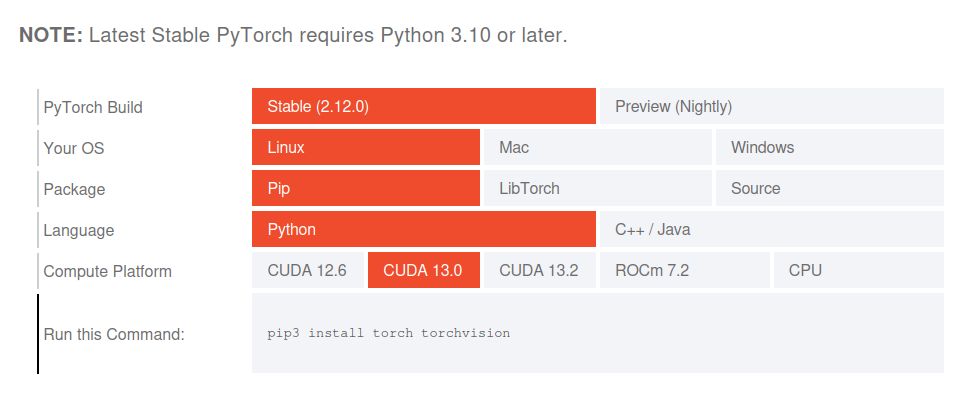

```bash
uv add --active torchvision
```

In [34]:
import torch


torch.__version__

'2.12.0+cu130'

In [35]:
import torch


torch.cuda.is_available()

True

In [56]:
import torch


print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.12.0+cu130
13.0
True
1
NVIDIA GB10


### Data sampling (suite)

In [36]:
import torch
from torch.utils.data import DataLoader, Dataset


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(txt)
        # Tokenizes the entire text
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

### A.6 Dataset, Dataloader

In [38]:
X_train = torch.tensor(
    [[-1.2, 3.1], [-0.9, 2.9], [-0.5, 2.6], [2.3, -1.1], [2.7, -1.5]]
)
y_train = torch.tensor([0, 0, 0, 1, 1])
X_test = torch.tensor(
    [
        [-0.8, 2.8],
        [2.6, -1.6],
    ]
)
y_test = torch.tensor([0, 1])

In [39]:
from torch.utils.data import Dataset


class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    def __len__(self):
        return self.labels.shape[0]


train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test, y_test)

In [40]:
print(len(train_ds))

5


In [41]:
torch.manual_seed(123)

train_loader = DataLoader(dataset=train_ds, batch_size=2, shuffle=True, num_workers=0)

test_loader = DataLoader(dataset=test_ds, batch_size=2, shuffle=False, num_workers=0)

In [43]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx + 1}:", x, y)

Batch 1: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 2: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])
Batch 3: tensor([[ 2.7000, -1.5000]]) tensor([1])


In [44]:
train_loader = DataLoader(
    dataset=train_ds, batch_size=2, shuffle=True, num_workers=0, drop_last=True
)

In [46]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx + 1}:", x, y)

Batch 1: tensor([[-0.9000,  2.9000],
        [ 2.3000, -1.1000]]) tensor([0, 1])
Batch 2: tensor([[ 2.7000, -1.5000],
        [-0.5000,  2.6000]]) tensor([1, 0])


### Data sampling (suite)

In [47]:
def create_dataloader_v1(
    txt,
    batch_size=4,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
    num_workers=0,
):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )
    return dataloader

In [48]:
with open("the-verdict.txt", encoding="utf-8") as f:
    raw_text = f.read()
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [49]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


In [52]:
# max_length=2, stride=2
with open("the-verdict.txt", encoding="utf-8") as f:
    raw_text = f.read()
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=2, stride=2, shuffle=False
)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 40, 367]]), tensor([[ 367, 2885]])]
[tensor([[2885, 1464]]), tensor([[1464, 1807]])]


In [53]:
# max_length=8, stride=2
with open("the-verdict.txt", encoding="utf-8") as f:
    raw_text = f.read()
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=8, stride=2, shuffle=False
)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)
second_batch = next(data_iter)
print(second_batch)

[tensor([[  40,  367, 2885, 1464, 1807, 3619,  402,  271]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899]])]
[tensor([[ 2885,  1464,  1807,  3619,   402,   271, 10899,  2138]]), tensor([[ 1464,  1807,  3619,   402,   271, 10899,  2138,   257]])]


In [54]:
# max_length=8, stride=2, batch_size=2
with open("the-verdict.txt", encoding="utf-8") as f:
    raw_text = f.read()
dataloader = create_dataloader_v1(
    raw_text, batch_size=2, max_length=8, stride=2, shuffle=False
)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)
second_batch = next(data_iter)
print(second_batch)

[tensor([[   40,   367,  2885,  1464,  1807,  3619,   402,   271],
        [ 2885,  1464,  1807,  3619,   402,   271, 10899,  2138]]), tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899],
        [ 1464,  1807,  3619,   402,   271, 10899,  2138,   257]])]
[tensor([[ 1807,  3619,   402,   271, 10899,  2138,   257,  7026],
        [  402,   271, 10899,  2138,   257,  7026, 15632,   438]]), tensor([[ 3619,   402,   271, 10899,  2138,   257,  7026, 15632],
        [  271, 10899,  2138,   257,  7026, 15632,   438,  2016]])]


In [57]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=4, stride=4, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


## 2.7 - Creating token embeddings

In [58]:
input_ids = torch.tensor([2, 3, 5, 1])

In [59]:
vocab_size = 6
output_dim = 3

In [60]:
torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [61]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [62]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


## 2.8 - Encoding word positions

In [63]:
vocab_size = 50257
output_dim = 256
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [64]:
max_length = 4
dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length, stride=max_length, shuffle=False
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [65]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


In [66]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


In [67]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])
